/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


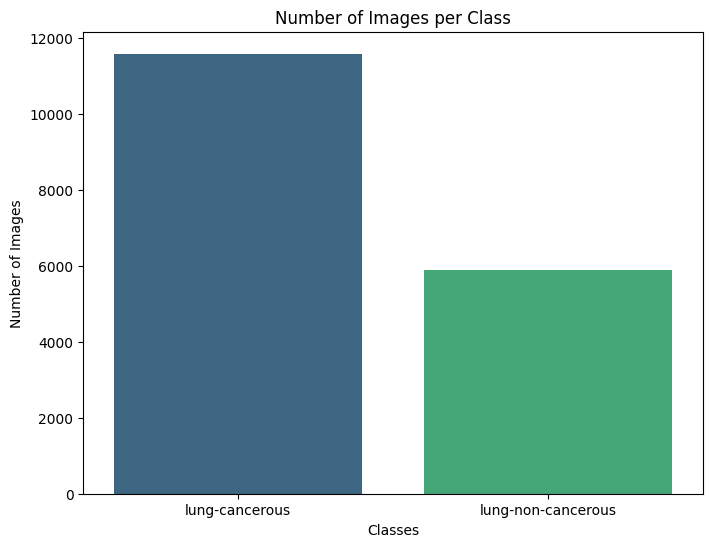

Visualizing lung-cancerous images:


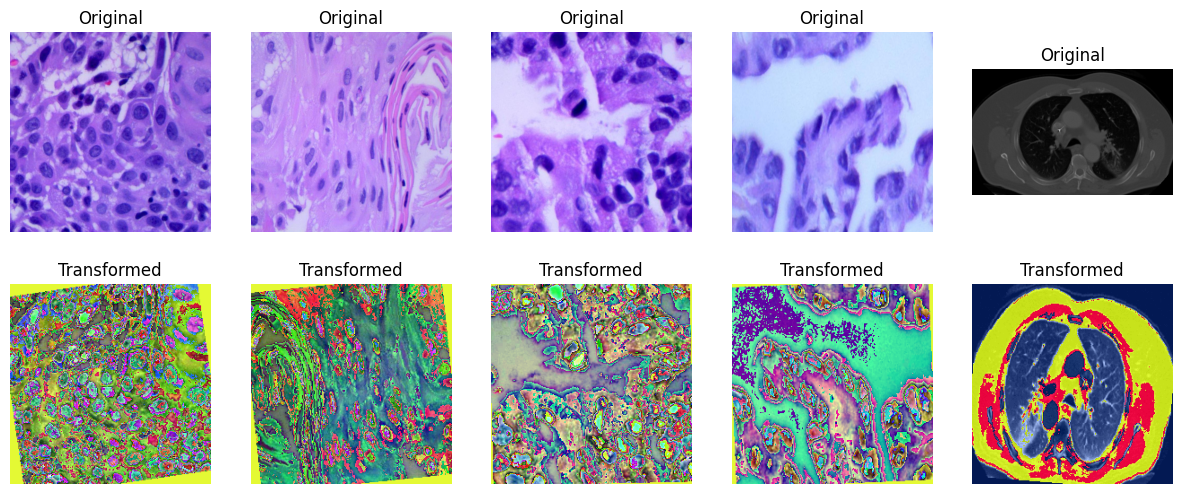

Visualizing lung-non-cancerous images:


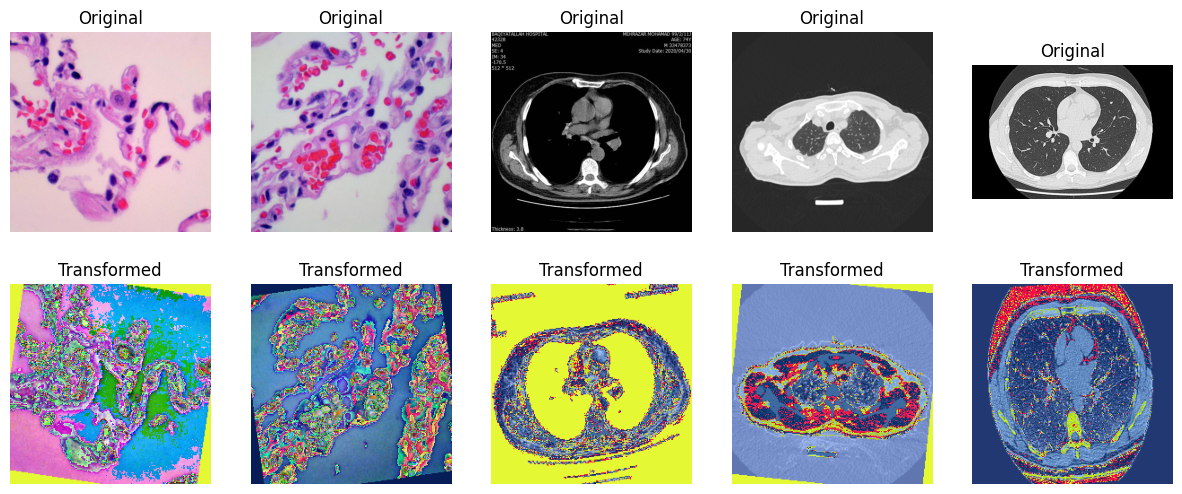

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 2, 224, 224]              56
              ReLU-2          [-1, 2, 224, 224]               0
         MaxPool2d-3          [-1, 2, 112, 112]               0
            Conv2d-4          [-1, 3, 112, 112]              57
              ReLU-5          [-1, 3, 112, 112]               0
         MaxPool2d-6            [-1, 3, 28, 28]               0
            Conv2d-7            [-1, 3, 28, 28]              84
              ReLU-8            [-1, 3, 28, 28]               0
         MaxPool2d-9              [-1, 3, 7, 7]               0
          Flatten-10                  [-1, 147]               0
           Linear-11                    [-1, 7]           1,036
             ReLU-12                    [-1, 7]               0
           Linear-13                    [-1, 2]              16
Total params: 1,249
Trainable params: 1

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    log_loss,
    auc
)
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torchsummary import summary


# Set seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# 1. Custom Dataset
class LungCancerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# 2. Loading and preprocessing the data
def load_and_preprocess_data(data_dir):
    classes = ['lung-cancerous', 'lung-non-cancerous']
    image_paths = []
    labels = []
    class_counts = {class_name: 0 for class_name in classes}

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(i)
            class_counts[class_name] += 1

    return image_paths, np.array(labels), class_counts

# 3. Visualize images before and after preprocessing
def visualize_images(image_paths, transform, num_images=5):
    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))
    for i, img_path in enumerate(image_paths[:num_images]):
        image = Image.open(img_path).convert('RGB')
        axes[0, i].imshow(image)
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        transformed_image = transform(image)
        axes[1, i].imshow(transforms.ToPILImage()(transformed_image))
        axes[1, i].set_title("Transformed")
        axes[1, i].axis('off')
    plt.show()

# 4. Plot number of images per class
def plot_class_distribution(class_counts):
    plt.figure(figsize=(8,6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.title('Number of Images per Class')
    plt.show()

# 5. Splitting the balanced data
def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.50, stratify=y_train, random_state=42
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# Custom CNN1 1,249 PM Model
class CustomCNN1(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN1, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(2, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),

            nn.Conv2d(3, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 7 * 7, 7),
            nn.ReLU(),
            nn.Linear(7, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Custom CNN2 1,754PM Model
class CustomCNN2(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN2, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(3, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),

            nn.Conv2d(3, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 7 * 7, 10),
            nn.ReLU(),
            nn.Linear(10, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Custom CNN3 10,967 PM Model
class CustomCNN3(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN3, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(2, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(4, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6 * 14 * 14, 9),
            nn.ReLU(),
            nn.Linear(9, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Custom CNN4 105,344 PM Model
class CustomCNN4(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN4, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),

            nn.Conv2d(16, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(40 * 7 * 7, 50),
            nn.ReLU(),
            nn.Linear(50, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Custom CNN5 1,210,402 PM Model
class CustomCNN5(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN5, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 28 * 28, 48),
            nn.ReLU(),
            nn.Linear(48, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=100, device='cuda'):
    best_val_loss = float('inf')
    patience = 5
    counter = 0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / train_total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.9f}, Train Acc: {train_acc:.9f}')
        print(f'Val Loss: {val_loss:.9f}, Val Acc: {val_acc:.9f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping after {epoch+1} epochs')
                break

    return model, train_losses, val_losses, train_accs, val_accs

# 7. Testing function with evaluation metrics
def test_model(model, test_loader, criterion, device='cuda'):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)
    test_acc = test_correct / test_total

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Calculate overall metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    roc_auc_value = roc_auc_score(all_labels, all_probs)
    
    # Additional metrics
    specificity = recall_score(all_labels, all_preds, pos_label=0)  # Specificity is recall of negative class
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)
    log_loss_val = log_loss(all_labels, all_probs)
    
    # ROC curve metrics
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # Precision-Recall curve metrics
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_curve, precision_curve)

    # Calculate per-class metrics
    per_class_precision = precision_score(all_labels, all_preds, average=None)
    per_class_recall = recall_score(all_labels, all_preds, average=None)
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    print(f'Test Acc: {test_acc:.9f}')
    print(f'Test Loss: {test_loss:.9f}')
    print(f'Overall Precision: {precision:.9f}')
    print(f'Overall Recall: {recall:.9f}')
    print(f'Overall F1 Score: {f1:.9f}')
    print(f'AUC: {roc_auc_value:.9f}')
    print(f'Specificity: {specificity:.9f}')
    print(f'Balanced Accuracy: {balanced_acc:.9f}')
    print(f'Matthews Correlation Coefficient: {mcc:.9f}')
    print(f'Log Loss: {log_loss_val:.9f}')
    print(f'Optimal Threshold: {optimal_threshold:.9f}')
    print(f'PR-AUC: {pr_auc:.9f}')
    
    print('\nPer-class metrics:')
    class_names = ['Non-Cancerous', 'Cancerous']
    for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
        print(f'\n{class_names[i]}:')
        print(f'Precision: {p:.9f}')
        print(f'Recall: {r:.9f}')
        print(f'F1 Score: {f:.9f}')

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall_curve, precision_curve, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

    plot_confusion_matrix(all_labels, all_preds)

# Define plot accuracy
def plot_accuracy(train_accs, val_accs):
    plt.figure(figsize=(10,5))
    epochs = range(1, len(train_accs) + 1)
    plt.plot(epochs, train_accs, label='Train Accuracy', marker='o')
    plt.plot(epochs, val_accs, label='Validation Accuracy', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define plot_loss
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10,5))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define plot_confusion_matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Cancerous', 'Cancerous'],
        yticklabels=['Non-Cancerous', 'Cancerous']
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    
    # Add per-class metrics to the plot
    class_names = ['Non-Cancerous', 'Cancerous']
    for i in range(len(class_names)):
        true_pos = cm[i,i]
        false_pos = cm[:,i].sum() - true_pos
        false_neg = cm[i,:].sum() - true_pos
        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        plt.text(2.5, i + 0.5, f'P: {precision:.3f}\nR: {recall:.3f}\nF1: {f1:.3f}', 
                verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
# Main Execution
data_dir = "/kaggle/input/lung-cancer-two-class-dataset-combined-4-tomal/lung-cancer-two-class-dataset-combined-4"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and preprocess data
image_paths, labels, class_counts = load_and_preprocess_data(data_dir)

# Plot class distribution
plot_class_distribution(class_counts)

# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation and test transforms without data augmentation
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Visualize images before and after preprocessing
for class_name in ['lung-cancerous', 'lung-non-cancerous']:
    class_image_paths = [
        img_path for img_path, label in zip(image_paths, labels)
        if label == ['lung-cancerous', 'lung-non-cancerous'].index(class_name)
    ]
    print(f"Visualizing {class_name} images:")
    visualize_images(class_image_paths, train_transform)

# Split data
X_train, X_val, X_test, y_train, y_val, y_test = split_data(image_paths, labels)
batch_size = 48

# Create datasets
train_dataset = LungCancerDataset(X_train, y_train, transform=train_transform)
val_dataset = LungCancerDataset(X_val, y_val, transform=test_transform)
test_dataset = LungCancerDataset(X_test, y_test, transform=test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Create and summarize model1
model1 = CustomCNN1(num_classes=2).to(device)
summary(model1, (3, 224, 224))

# Create and summarize model2
model2 = CustomCNN2(num_classes=2).to(device)
summary(model2, (3, 224, 224))

# Create and summarize model3
model3 = CustomCNN3(num_classes=2).to(device)
summary(model3, (3, 224, 224))

# Create and summarize model4
model4 = CustomCNN4(num_classes=2).to(device)
summary(model4, (3, 224, 224))

# Create and summarize model5
model5 = CustomCNN5(num_classes=2).to(device)
summary(model5, (3, 224, 224))

# ========================= Define function to train + test a single model =========================
def run_experiment(model_cls, device, train_loader, val_loader, test_loader):
    model = model_cls(num_classes=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=5
    )
    # print(f"Running experiment with seed: {seed}")
    trained_model, train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, nn.CrossEntropyLoss(),
        optimizer, scheduler, num_epochs=100, device=device
    )
    plot_loss(train_losses, val_losses)
    plot_accuracy(train_accs, val_accs)
    best_model = model_cls(num_classes=2).to(device)
    best_model.load_state_dict(torch.load('best_model.pth'))
    test_model(best_model, test_loader, nn.CrossEntropyLoss(), device=device)


In [5]:
from sklearn.metrics import balanced_accuracy_score

Epoch 1/100: 100%|██████████| 128/128 [00:26<00:00,  4.82it/s]


Epoch 1/100
Train Loss: 0.204519311, Train Acc: 0.914580265
Val Loss: 0.104183214, Val Acc: 0.945671739


Epoch 2/100: 100%|██████████| 128/128 [00:25<00:00,  4.94it/s]


Epoch 2/100
Train Loss: 0.107256559, Train Acc: 0.950090002
Val Loss: 0.102724791, Val Acc: 0.952217313


Epoch 3/100: 100%|██████████| 128/128 [00:25<00:00,  5.02it/s]


...

Epoch 21/100
Train Loss: 0.070406341, Train Acc: 0.968581247
Val Loss: 0.085630215, Val Acc: 0.966781214


Epoch 22/100: 100%|██████████| 128/128 [00:26<00:00,  4.90it/s]


Epoch 22/100
Train Loss: 0.074318384, Train Acc: 0.967108493
Val Loss: 0.072133085, Val Acc: 0.973163148


Epoch 23/100: 100%|██████████| 128/128 [00:27<00:00,  4.63it/s]


Epoch 23/100
Train Loss: 0.070238330, Train Acc: 0.971526755
Val Loss: 0.072544919, Val Acc: 0.971854034
Early stopping after 23 epochs


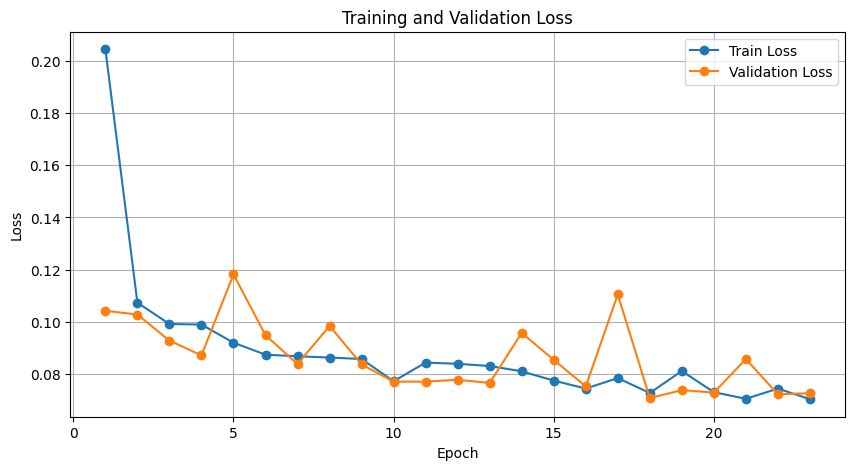

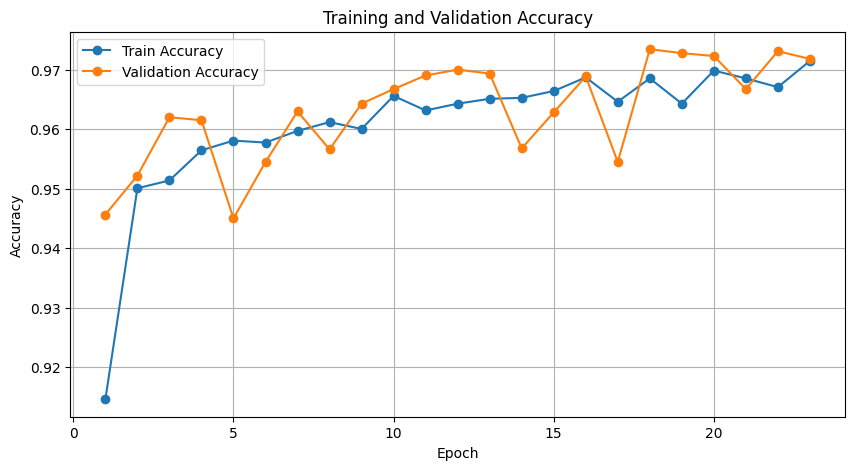

Test Acc: 0.973849971
Test Loss: 0.069842369
Overall Precision: 0.973899380
Overall Recall: 0.973849971
Overall F1 Score: 0.973869913
AUC: 0.996840828
Specificity: 0.978711162
Balanced Accuracy: 0.971488309
Matthews Correlation Coefficient: 0.941539484
Log Loss: 0.069842370
Optimal Threshold: 0.427433521
PR-AUC: 0.994038858

Per-class metrics:

Non-Cancerous:
Precision: 0.981818182
Recall: 0.978711162
F1 Score: 0.980262210

Cancerous:
Precision: 0.958286359
Recall: 0.964265457
F1 Score: 0.961266610


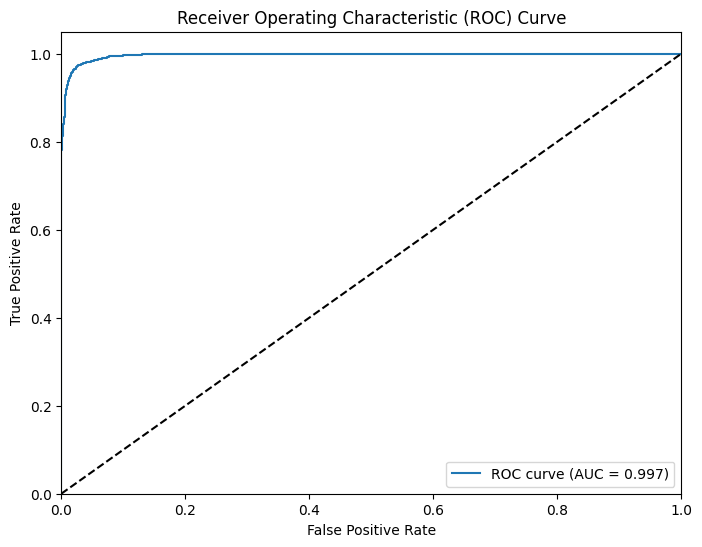

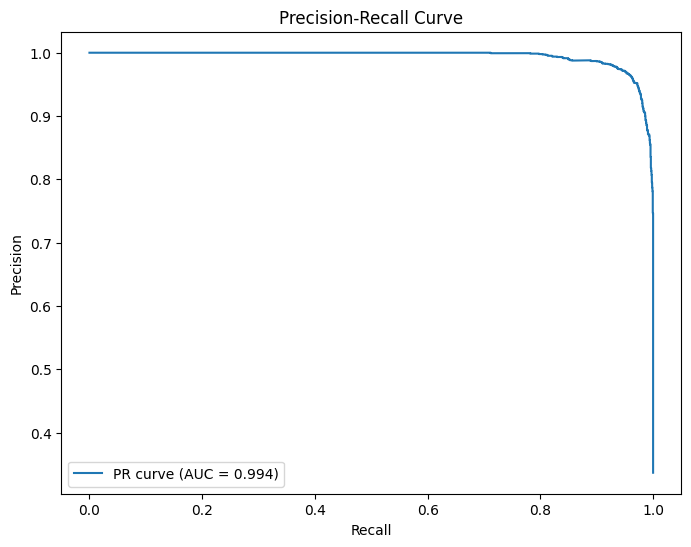

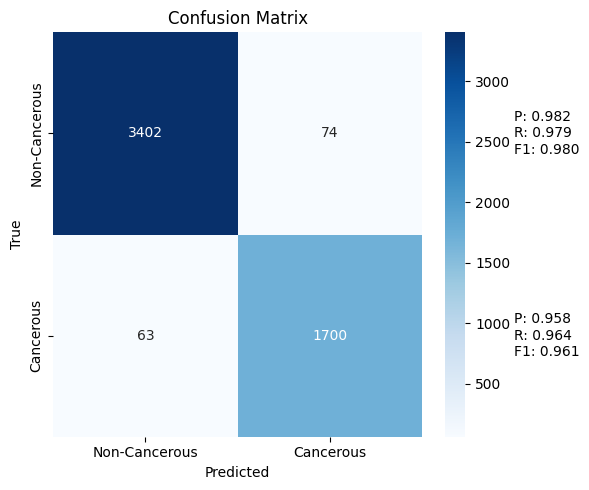

In [6]:

# =====================================Train model1======================================
run_experiment(CustomCNN1, device, train_loader, val_loader, test_loader)

Epoch 1/100: 100%|██████████| 128/128 [00:26<00:00,  4.77it/s]


Epoch 1/100
Train Loss: 0.437821028, Train Acc: 0.775650466
Val Loss: 0.157292571, Val Acc: 0.932253314


Epoch 2/100: 100%|██████████| 128/128 [00:26<00:00,  4.76it/s]


Epoch 2/100
Train Loss: 0.138871440, Train Acc: 0.938962527
Val Loss: 0.125546925, Val Acc: 0.941744395


Epoch 3/100: 100%|██████████| 128/128 [00:26<00:00,  4.85it/s]


...

Epoch 19/100
Train Loss: 0.075324634, Train Acc: 0.965308460
Val Loss: 0.088672684, Val Acc: 0.960399280


Epoch 20/100: 100%|██████████| 128/128 [00:25<00:00,  4.95it/s]


Epoch 20/100
Train Loss: 0.077372310, Train Acc: 0.967763050
Val Loss: 0.083729237, Val Acc: 0.962362952


Epoch 21/100: 100%|██████████| 128/128 [00:30<00:00,  4.24it/s]


Epoch 21/100
Train Loss: 0.077263218, Train Acc: 0.965308460
Val Loss: 0.089613392, Val Acc: 0.961708395
Early stopping after 21 epochs


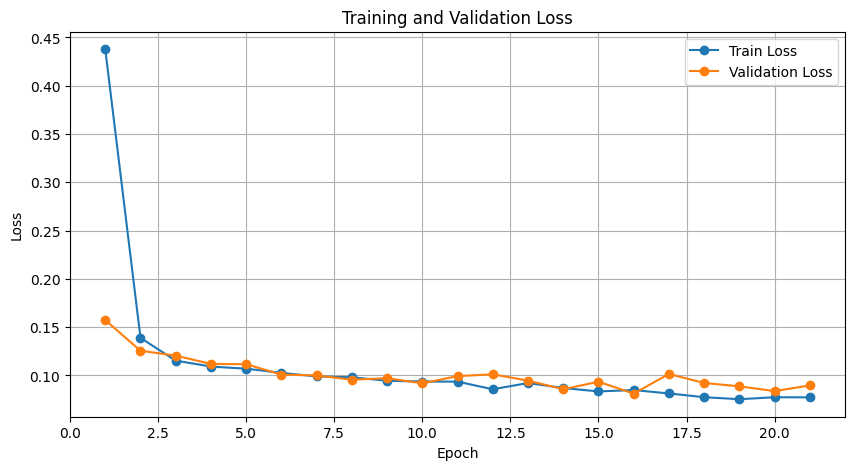

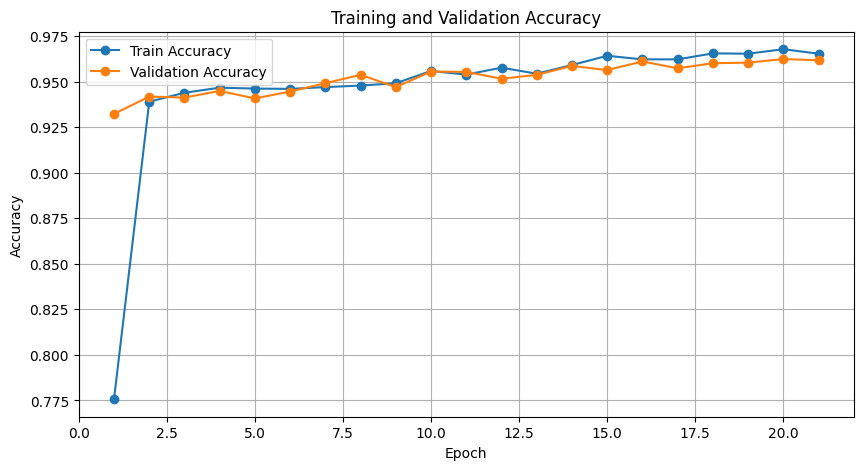

Test Acc: 0.962588280
Test Loss: 0.081289769
Overall Precision: 0.962588280
Overall Recall: 0.962588280
Overall F1 Score: 0.962588280
AUC: 0.995561575
Specificity: 0.971806674
Balanced Accuracy: 0.958109803
Matthews Correlation Coefficient: 0.916219607
Log Loss: 0.081289786
Optimal Threshold: 0.355332643
PR-AUC: 0.991761906

Per-class metrics:

Non-Cancerous:
Precision: 0.971806674
Recall: 0.971806674
F1 Score: 0.971806674

Cancerous:
Precision: 0.944412933
Recall: 0.944412933
F1 Score: 0.944412933


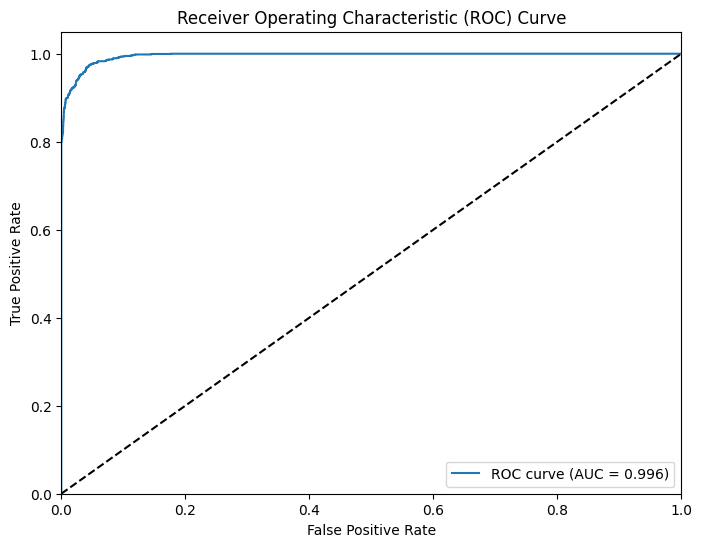

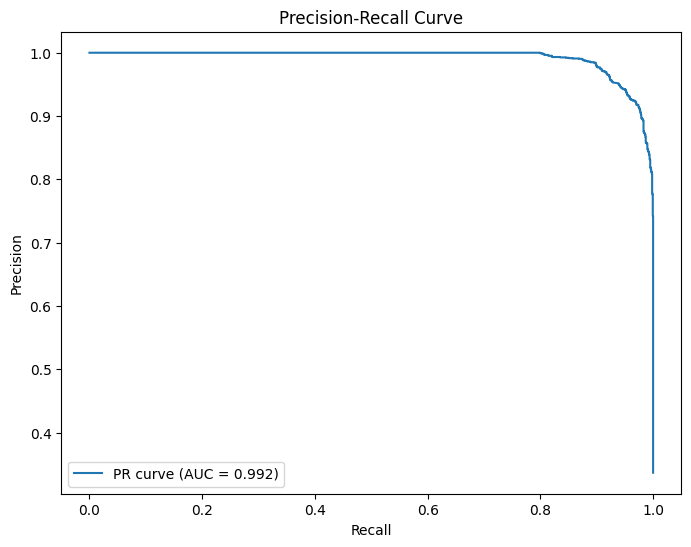

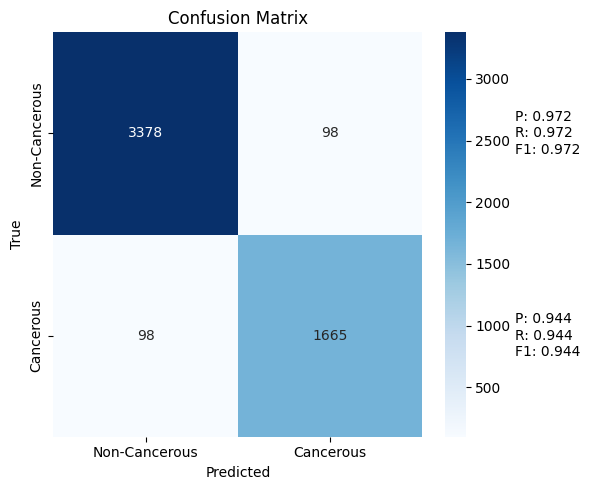

In [7]:


# =====================================Train model2======================================
run_experiment(CustomCNN2, device, train_loader, val_loader, test_loader)


Epoch 1/100: 100%|██████████| 128/128 [00:25<00:00,  4.93it/s]


Epoch 1/100
Train Loss: 0.227211895, Train Acc: 0.898870889
Val Loss: 0.179129798, Val Acc: 0.921125839


Epoch 2/100: 100%|██████████| 128/128 [00:26<00:00,  4.82it/s]


Epoch 2/100
Train Loss: 0.143031494, Train Acc: 0.937162494
Val Loss: 0.129279607, Val Acc: 0.939289805


Epoch 3/100: 100%|██████████| 128/128 [00:26<00:00,  4.90it/s]


...

Epoch 25/100
Train Loss: 0.019478961, Train Acc: 0.992308951
Val Loss: 0.050159206, Val Acc: 0.987236132


Epoch 26/100: 100%|██████████| 128/128 [00:27<00:00,  4.64it/s]


Epoch 26/100
Train Loss: 0.019524060, Train Acc: 0.992308951
Val Loss: 0.043397541, Val Acc: 0.988054328


Epoch 27/100: 100%|██████████| 128/128 [00:27<00:00,  4.71it/s]


Epoch 27/100
Train Loss: 0.031816311, Train Acc: 0.989036164
Val Loss: 0.050900284, Val Acc: 0.983472427
Early stopping after 27 epochs


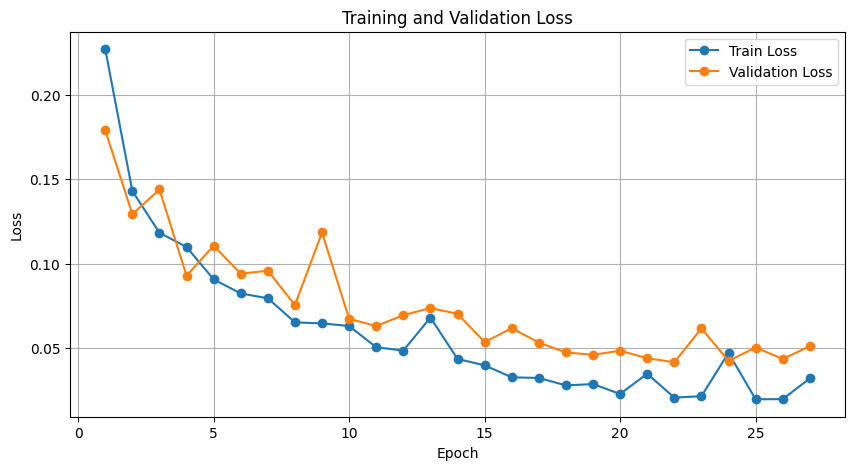

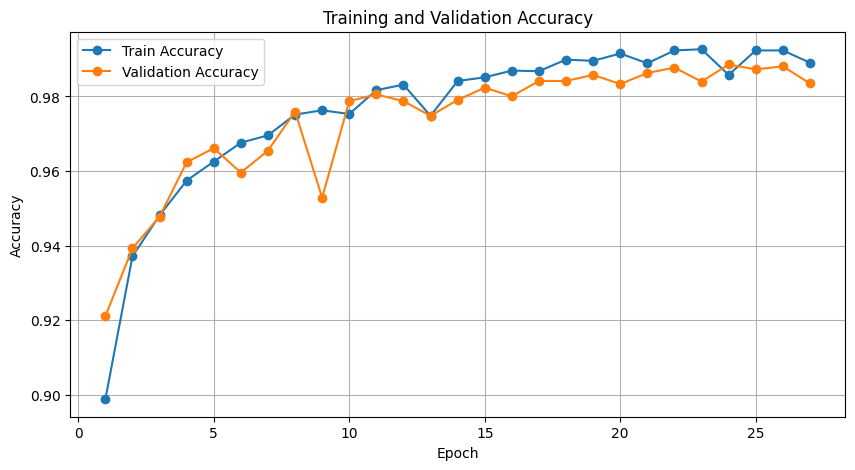

Test Acc: 0.986447795
Test Loss: 0.052938629
Overall Precision: 0.986436530
Overall Recall: 0.986447795
Overall F1 Score: 0.986437295
AUC: 0.998281221
Specificity: 0.991369390
Balanced Accuracy: 0.984056788
Matthews Correlation Coefficient: 0.969615001
Log Loss: 0.049225596
Optimal Threshold: 0.213547558
PR-AUC: 0.995700367

Per-class metrics:

Non-Cancerous:
Precision: 0.988242042
Recall: 0.991369390
F1 Score: 0.989803246

Cancerous:
Precision: 0.982876712
Recall: 0.976744186
F1 Score: 0.979800853


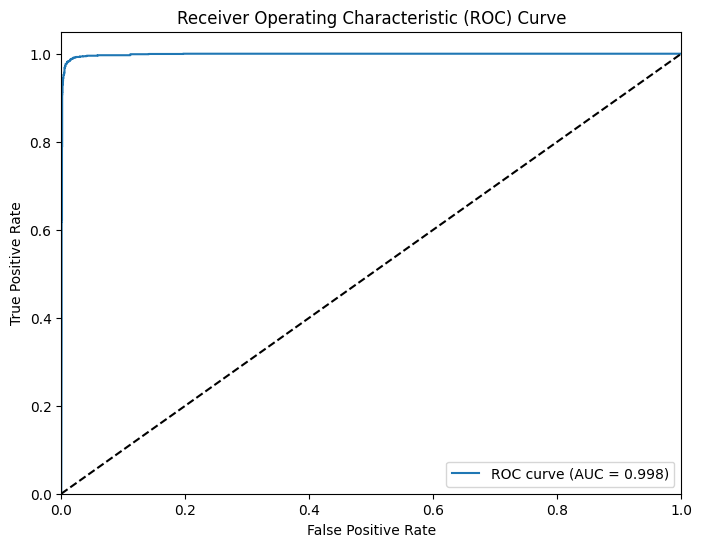

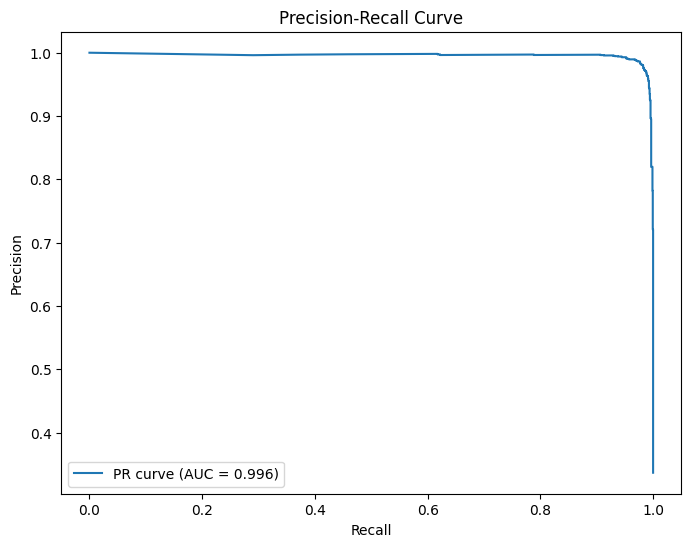

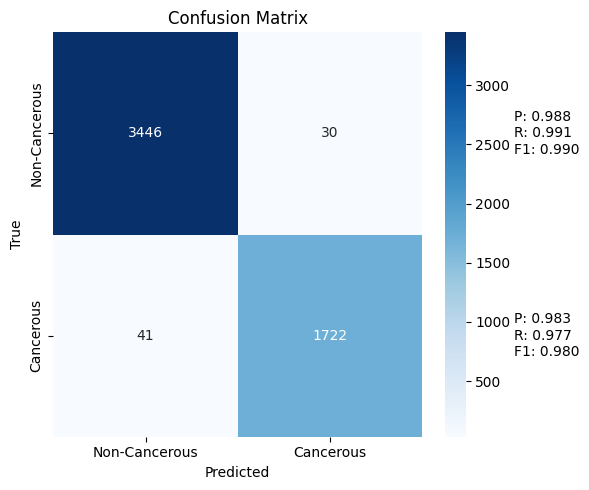

In [8]:

# =====================================Train model3======================================
run_experiment(CustomCNN3, device, train_loader, val_loader, test_loader)


Epoch 1/100: 100%|██████████| 128/128 [00:27<00:00,  4.71it/s]


Epoch 1/100
Train Loss: 0.206746197, Train Acc: 0.900180003
Val Loss: 0.142335477, Val Acc: 0.939617084


Epoch 2/100: 100%|██████████| 128/128 [00:25<00:00,  4.94it/s]


Epoch 2/100
Train Loss: 0.091074437, Train Acc: 0.952544592
Val Loss: 0.084062177, Val Acc: 0.958271969


Epoch 3/100: 100%|██████████| 128/128 [00:25<00:00,  4.98it/s]


...

Epoch 13/100
Train Loss: 0.017353596, Train Acc: 0.993781705
Val Loss: 0.036527381, Val Acc: 0.988545246


Epoch 14/100: 100%|██████████| 128/128 [00:25<00:00,  5.04it/s]


Epoch 14/100
Train Loss: 0.025571725, Train Acc: 0.990999836
Val Loss: 0.062116640, Val Acc: 0.978890525


Epoch 15/100: 100%|██████████| 128/128 [00:25<00:00,  5.12it/s]


Epoch 15/100
Train Loss: 0.019244811, Train Acc: 0.991327115
Val Loss: 0.037764553, Val Acc: 0.987563410
Early stopping after 15 epochs


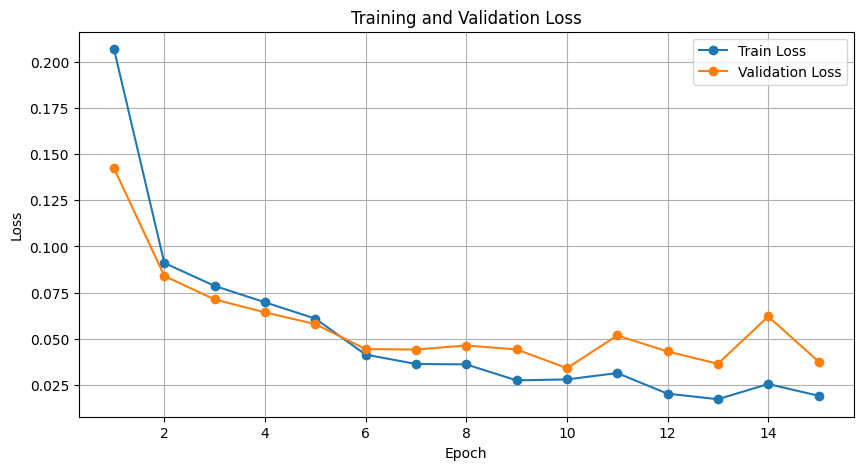

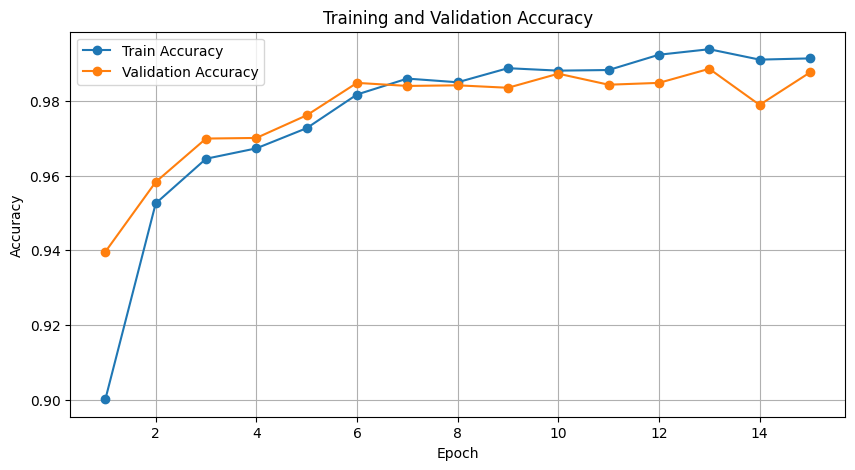

Test Acc: 0.987211300
Test Loss: 0.032975469
Overall Precision: 0.987209591
Overall Recall: 0.987211300
Overall F1 Score: 0.987210406
AUC: 0.999184424
Specificity: 0.990506329
Balanced Accuracy: 0.985610510
Matthews Correlation Coefficient: 0.971356869
Log Loss: 0.032975530
Optimal Threshold: 0.212120861
PR-AUC: 0.998319285

Per-class metrics:

Non-Cancerous:
Precision: 0.990221455
Recall: 0.990506329
F1 Score: 0.990363872

Cancerous:
Precision: 0.981271283
Recall: 0.980714691
F1 Score: 0.980992908


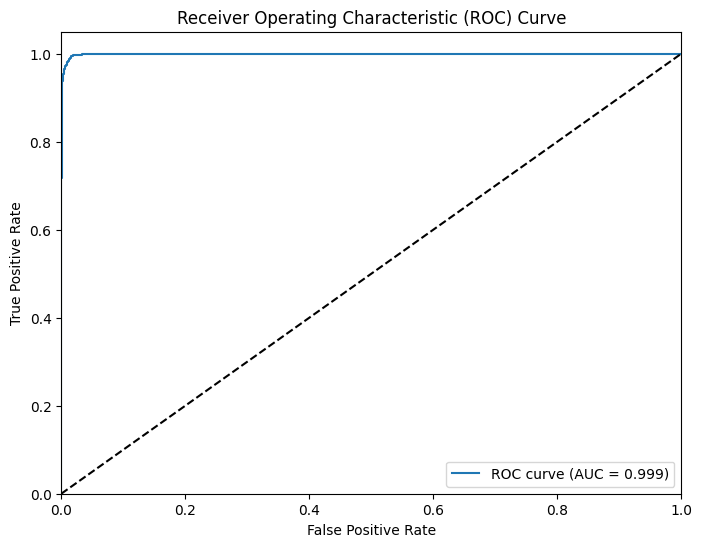

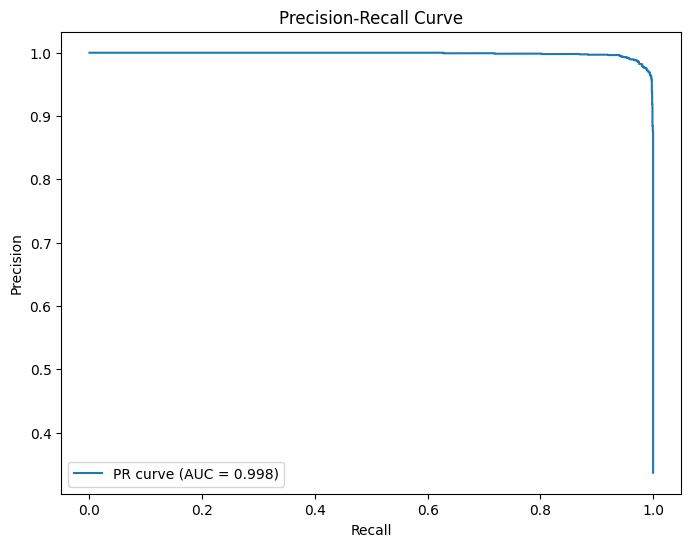

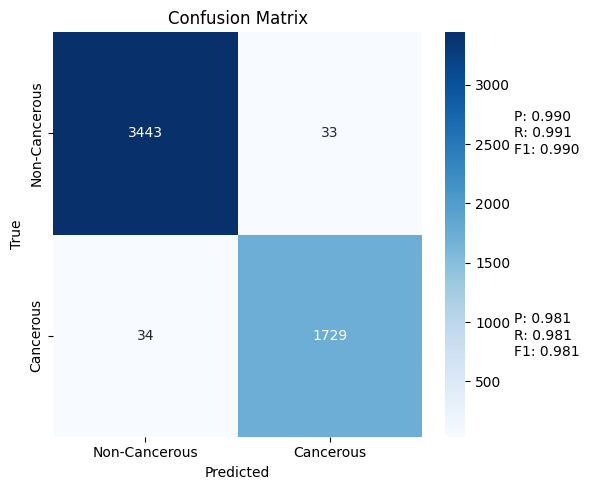

In [9]:

# =====================================Train model4======================================
run_experiment(CustomCNN4, device, train_loader, val_loader, test_loader)


Epoch 1/100: 100%|██████████| 128/128 [00:25<00:00,  5.12it/s]


Epoch 1/100
Train Loss: 0.166171051, Train Acc: 0.927835052
Val Loss: 0.092809949, Val Acc: 0.965472099


Epoch 2/100: 100%|██████████| 128/128 [00:24<00:00,  5.18it/s]


Epoch 2/100
Train Loss: 0.082667493, Train Acc: 0.963835706
Val Loss: 0.131207443, Val Acc: 0.950090002


Epoch 3/100: 100%|██████████| 128/128 [00:24<00:00,  5.25it/s]


...

Epoch 27/100
Train Loss: 0.004931104, Train Acc: 0.998690885
Val Loss: 0.042086823, Val Acc: 0.988708886


Epoch 28/100: 100%|██████████| 128/128 [00:25<00:00,  5.05it/s]


Epoch 28/100
Train Loss: 0.018593662, Train Acc: 0.993781705
Val Loss: 0.043858503, Val Acc: 0.989036164


Epoch 29/100: 100%|██████████| 128/128 [00:25<00:00,  4.96it/s]


Epoch 29/100
Train Loss: 0.006498868, Train Acc: 0.997218131
Val Loss: 0.070574895, Val Acc: 0.989363443
Early stopping after 29 epochs


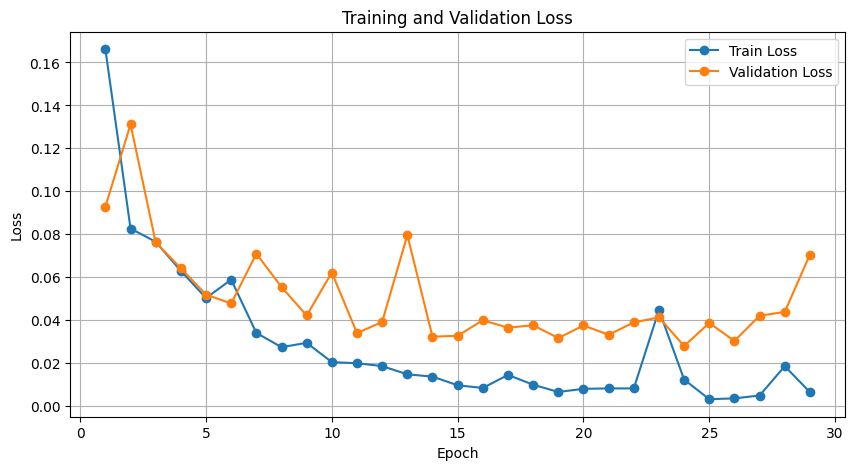

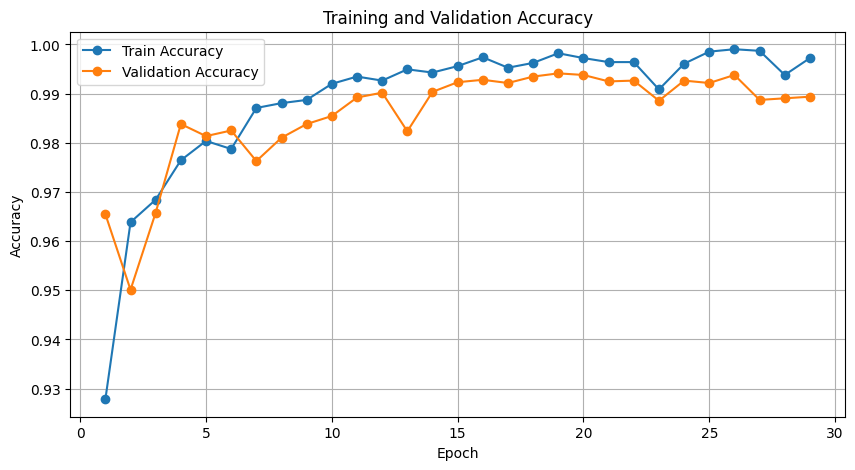

Test Acc: 0.992555831
Test Loss: 0.037506551
Overall Precision: 0.992631555
Overall Recall: 0.992555831
Overall F1 Score: 0.992568602
AUC: 0.999075420
Specificity: 0.990794016
Balanced Accuracy: 0.993411756
Matthews Correlation Coefficient: 0.983443222
Log Loss: 0.036454447
Optimal Threshold: 0.744357765
PR-AUC: 0.997926529

Per-class metrics:

Non-Cancerous:
Precision: 0.997971602
Recall: 0.990794016
F1 Score: 0.994369857

Cancerous:
Precision: 0.982102908
Recall: 0.996029495
F1 Score: 0.989017178


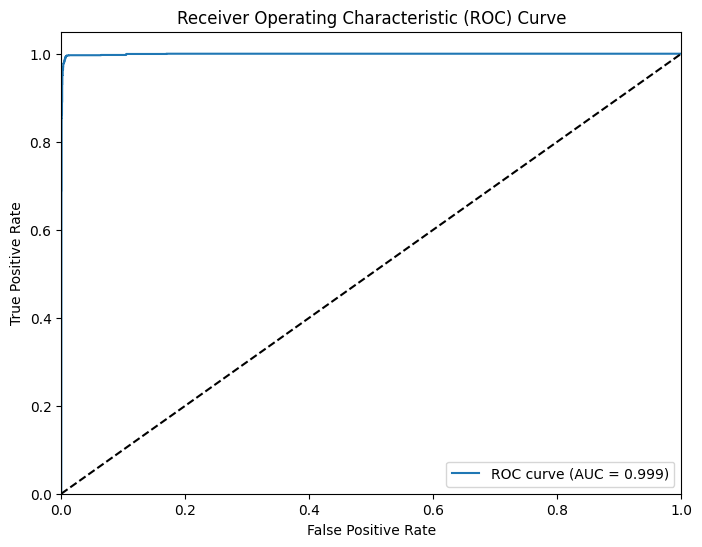

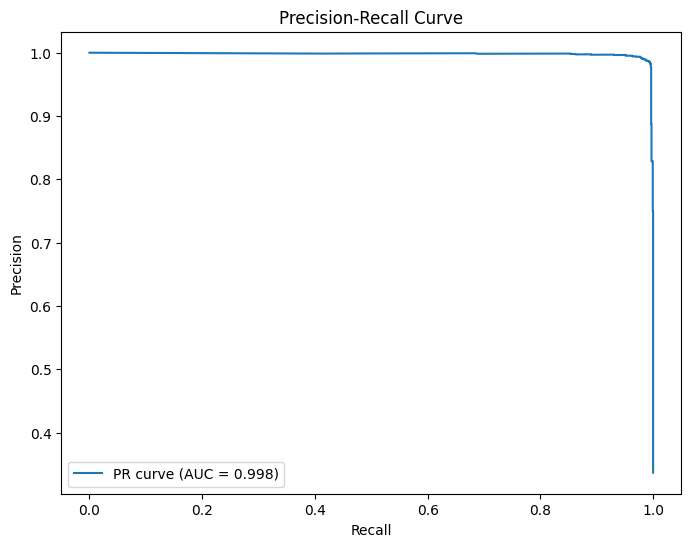

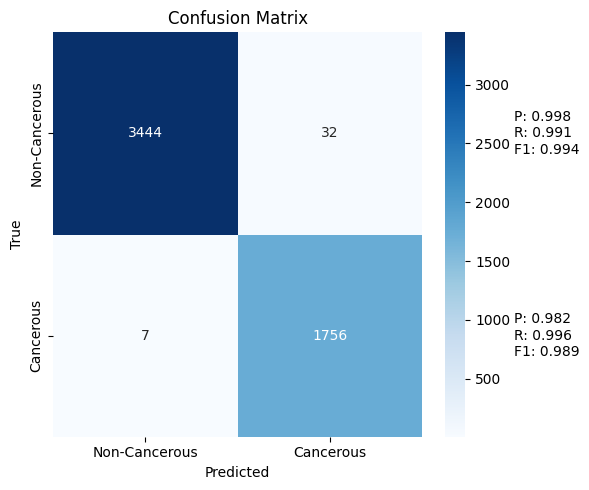

In [10]:

# =====================================Train model5======================================
run_experiment(CustomCNN5, device, train_loader, val_loader, test_loader)

